# Resistance mutations in aquatic plastisphere microbiomes

All script files are located in `sbatch_files/`. 

Steps before this notebook:
1. Download the fastq data (specified in *download.txt*) using `download.sh` 
2. Run Pipeline 1, see TODO_URL_TO_IT for more details. TODO: Ok to link to it or just describe it?
3. Download the card database using `download_card.sh`
4. Build the database for MuMaMe using `mumame_build.sh`
5. Run MuMaMe using `split_mumame.sh`, it will be grouped according to *beginning_filenames.txt*, in order to speed up the operation.
6. The files *\*.table.txt* and *\*.per-mutation.txt* will be used below.

# Data analysis
## Import data

In [67]:
rm(list = ls())
# Load Libraries
library("tidyverse")

# List all relevant files
all_files_list <- list.files(path = "Mumame_results", pattern = "*.per-mutation.txt", full.names = TRUE) 
# See also pattern = "*.table.txt"
# per-mutation splits the Accession into one line per mutation, and uses the same hits for all. Easier with splitting below but result feels it could be wrong?

# Create the beginnings of the large dataframe
df_counts <- read_tsv(all_files_list[1], show_col_types = FALSE)

# Loop over all files, joining it to the larger dataframe. 
for (file in all_files_list[-1]) {
  df_counts <- read_tsv(file = file, show_col_types = FALSE) %>%
    full_join(df_counts, ., by = "Accession")
}
# Rename to not confuse with ARO accession later
df_counts <- df_counts %>%
  rename(Description = Accession)
dim(df_counts)

[1]  492 1573

## Import metadata

In [68]:
# Load in the metadata tables
snps <- read_tsv("card-data/snps.txt", show_col_types = FALSE)
cat("SNPS\n Dimensions of unmodified: "); cat(dim(snps))
snps <- snps %>%
  select(-citation) %>%
  unique.data.frame()
cat("\n Dimensions of filtered:   "); cat(dim(snps))

aro_index <- read_tsv("card-data/aro_index.tsv", show_col_types = FALSE)
cat("\n\nARO_INDEX\n Dimensions of unmodified: "); cat(dim(aro_index))
aro_index <- aro_index %>%
  # Rename it to match for later
  rename(Accession = `ARO Accession`) %>%
  mutate(Accession = as.double(str_remove(Accession, "ARO:"))) %>%
  select(Accession, `AMR Gene Family`, `Drug Class`, `Resistance Mechanism`) %>%
  unique.data.frame()
cat("\n Dimensions of filtered:   "); cat(dim(aro_index))

aro_categories <- read_tsv("card-data/aro_categories.tsv", show_col_types = FALSE)
aro_categories_index <- read_tsv("card-data/aro_categories_index.tsv", show_col_types = FALSE)

sample_metadata <- read_tsv("sample_metadata.tsv", show_col_types = FALSE)
sample_metadata <- sample_metadata %>% 
    select(run_accession, study_accession, Sampletype, Substrate, Latitude, Longitude)

SNPS
 Dimensions of unmodified: 3247 8
 Dimensions of filtered:   2711 7

ARO_INDEX
 Dimensions of unmodified: 6444 12
 Dimensions of filtered:   6439 4

## To be removed?

In [69]:
# Some of the duplicates before filtered snps.txt:
#'N499T:Mycobacterium tuberculosis gyrB mutant conferring resistance to fluoroquinolones'
#'E501D:Mycobacterium tuberculosis gyrB mutant conferring resistance to fluoroquinolones'
#'S441Q:Mycobacterium tuberculosis rpoB with mutations conferring resistance to rifampicin'
#'D142G:Mycobacterium tuberculosis katG mutations conferring resistance to isoniazid'
#'Q432K:Mycobacterium tuberculosis rpoB with mutations conferring resistance to rifampicin'
#'D435A:Mycobacterium tuberculosis rpoB with mutations conferring resistance to rifampicin'
#'H445P:Mycobacterium tuberculosis rpoB with mutations conferring resistance to rifampicin'
#'S441L:Mycobacterium tuberculosis rpoB with mutations conferring resistance to rifampicin'
#'Y334H:Mycobacterium tuberculosis embB mutant conferring resistance to ethambutol'
#'A504V:Mycobacterium tuberculosis gyrB mutant conferring resistance to fluoroquinolones'
#'R463L:Mycobacterium tuberculosis katG mutations conferring resistance to isoniazid'
#'S450F:Mycobacterium tuberculosis rpoB with mutations conferring resistance to rifampicin'
#'H445N:Mycobacterium tuberculosis rpoB with mutations conferring resistance to rifampicin'
#'I491F:Mycobacterium tuberculosis rpoB with mutations conferring resistance to rifampicin'
#'V170F:Mycobacterium tuberculosis rpoB with mutations conferring resistance to rifampicin'

## Sanity checks
# Show one row which contain data for multiple samples
# For per-mutation.txt
#df_counts[which(df_counts["Accession"] == "A67T:Staphylococcus aureus fusA with mutation conferring resistance to fusidic acid"), c(1:5, 39:63, 1100:1103)]
#df_counts[which(df_counts["Accession"] == "V90A:Staphylococcus aureus fusA with mutation conferring resistance to fusidic acid"), c(1:5, 39:63, 1100:1103)]
# Below for table.txt
#df_counts[which(df_counts["Accession"] == "A67T+V90A:Staphylococcus aureus fusA with mutation conferring resistance to fusidic acid"), c(1:5, 39:63, 1100:1103)]

## Relative Abundances

In [70]:
# Get readcount before deleting that row
df_readcount <- df_counts[which(df_counts[, 1] == "TOTAL READS:"), ]
df_counts <- df_counts[-which(df_counts$Description == "TOTAL READS:"), ]

# Get relative abundances for each sample, separate for forward and reverse:
df_relative <- df_counts %>%
  mutate(across(ends_with('-Mut'), ~ . / (. + get(str_replace(cur_column(), "-Mut$", "-WT"))), .names = "{.col}_relative")) %>%
  rename_at(vars(ends_with('_relative')), ~ str_remove(., "\\_val-Mut")) %>%
  select(-ends_with(c("-Mut", "-WT"))) %>%
  rename_at(vars(ends_with('_relative')), ~ str_remove(., "\\_relative"))
#head(df_relative)
# Replace all NA:s with zeros?
#df_relative %>%
#  mutate_all(~replace(., is.na(.), 0)) %>%
#  select(-Accession)

# Identify Inf:s
#df_counts[which(df_relative$DRR528401_1_relative == Inf), c("Accession", "DRR528401_1_val-Mut", "DRR528401_1_val-WT", "DRR528402_1_val-Mut", "DRR528402_1_val-WT")]
#df_relative[which(df_relative$DRR528401_1_relative == Inf), c("Accession", "DRR528401_1_relative", "DRR528402_1_relative")]

## Transposing the dataframe

In [71]:
# Gives us a dataframe where row = sample and column = mutation
df_transposed <- df_relative %>%
    column_to_rownames(var = "Description") %>%
    rownames_to_column() %>%  
    pivot_longer(-rowname) %>% 
    pivot_wider(names_from=rowname, values_from=value) %>%
    rename(Sample = name)

# Replace all NA:s with zeros (copied from above), needed because '1 + NA = NA'
df_transposed <- df_transposed %>%
  mutate_all(~replace(., is.na(.), 0)) 

non_zero_count <- colSums(df_transposed != 0) # Count non-zero values per column
selected_cols <- names(non_zero_count[non_zero_count > 3]) # Get mutations with more than 3 non-zero values
df_transposed_filtered <- df_transposed[, selected_cols] # Filter the table for selected mutations
cat("\nDim unmodified: ", dim(df_transposed))
cat("\nDim filtered:   ", dim(df_transposed_filtered))


Dim unmodified:  786 492
Dim filtered:    786 212

## Create genes metadata dataframe

In [96]:
# 1. Mumame -> shortname
# 2. shortname -> snps.txt -> aro number
# 3. aro number -> aro_index.tsv -> categories

df_genes_metadata <- df_relative %>%
    # Extract and add mutation names (Note "Wildtype" in some)
    mutate(Mutations = str_split_i(Description, ":", i = 1),
           Name = str_split_i(Description, ":", i = 2)) %>%
    # Split further? Not needed if use per-mutation
        #df_counts$mutations %>%
        #    str_split("\\+")
    # Add real accession from snps to the dataframe
    left_join(., snps, by = c("Name", "Mutations")) %>%
    # Add the categories from aro_index 
    left_join(aro_index, by = "Accession")

df_genes_metadata[which(df_genes_metadata$Description == "N596S:Mycobacterium tuberculosis katG mutations conferring resistance to isoniazid"), ]
#print("df_genes_metadata")
#head(df_genes_metadata)
df_genes_metadata %>%
    filter(is.na(Accession))
#Detected an unexpected many-to-many relationship between `x` and `y`.
#ℹ Row 44 of `x` matches multiple rows in `y`.
#ℹ Row 2963 of `y` matches multiple rows in `x`.

Description,DRR528401_1,DRR528401_2,DRR528402_1,DRR528402_2,DRR528403_1,DRR528403_2,DRR528404_1,DRR528404_2,DRR528405_1,⋯,Mutations,Name,Accession,Model Type,Parameter Type,CARD Short Name,source,AMR Gene Family,Drug Class,Resistance Mechanism
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
N596S:Mycobacterium tuberculosis katG mutations conferring resistance to isoniazid,NA,NA,NA,NA,NA,NA,NA,NA,NA,⋯,N596S,Mycobacterium tuberculosis katG mutations conferring resistance to isoniazid,NA,NA,NA,NA,NA,NA,NA,NA


Description,DRR528401_1,DRR528401_2,DRR528402_1,DRR528402_2,DRR528403_1,DRR528403_2,DRR528404_1,DRR528404_2,DRR528405_1,⋯,Mutations,Name,Accession,Model Type,Parameter Type,CARD Short Name,source,AMR Gene Family,Drug Class,Resistance Mechanism
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
A67T:Staphylococcus aureus fusA with mutation conferring resistance to fusidic acid,0.000000000,0.00000000,0,0.25000000,1.000000000,0.00000000,0,0,0,⋯,A67T,Staphylococcus aureus fusA with mutation conferring resistance to fusidic acid,NA,NA,NA,NA,NA,NA,NA,NA
G33R:Escherichia coli GlpT with mutation conferring resistance to fosfomycin,0.000000000,0.00000000,0,0.01694915,0.005763689,0.00000000,NaN,NaN,NaN,⋯,G33R,Escherichia coli GlpT with mutation conferring resistance to fosfomycin,NA,NA,NA,NA,NA,NA,NA,NA
H57Y:Helicobacter pylori gyrA conferring resistance to fluoroquinolones,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,⋯,H57Y,Helicobacter pylori gyrA conferring resistance to fluoroquinolones,NA,NA,NA,NA,NA,NA,NA,NA
S63P:Helicobacter pylori gyrA conferring resistance to fluoroquinolones,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,⋯,S63P,Helicobacter pylori gyrA conferring resistance to fluoroquinolones,NA,NA,NA,NA,NA,NA,NA,NA
V77A:Helicobacter pylori gyrA conferring resistance to fluoroquinolones,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,⋯,V77A,Helicobacter pylori gyrA conferring resistance to fluoroquinolones,NA,NA,NA,NA,NA,NA,NA,NA
L487F:Clostridioides difficile rpoB with mutation conferring resistance to rifampicin,0.000000000,0.01176471,0,0.00000000,0.000000000,0.00000000,0,0,0,⋯,L487F,Clostridioides difficile rpoB with mutation conferring resistance to rifampicin,NA,NA,NA,NA,NA,NA,NA,NA
A314G:Mycobacterium tuberculosis embB mutant conferring resistance to ethambutol,0.000000000,0.25000000,NaN,NaN,0.000000000,0.00000000,NaN,NaN,NaN,⋯,A314G,Mycobacterium tuberculosis embB mutant conferring resistance to ethambutol,NA,NA,NA,NA,NA,NA,NA,NA
R485C:Mycobacterium tuberculosis gyrB mutant conferring resistance to fluoroquinolones,0.000000000,0.10526316,0,0.00000000,0.375000000,0.18181818,NaN,0,0,⋯,R485C,Mycobacterium tuberculosis gyrB mutant conferring resistance to fluoroquinolones,NA,NA,NA,NA,NA,NA,NA,NA
D500N:Mycobacterium tuberculosis gyrB mutant conferring resistance to fluoroquinolones,0.000000000,0.00000000,0,0.00000000,0.166666667,0.00000000,NaN,0,0,⋯,D500N,Mycobacterium tuberculosis gyrB mutant conferring resistance to fluoroquinolones,NA,NA,NA,NA,NA,NA,NA,NA


## Create sample metadata dataframe

In [73]:
df_sample_metadata <- df_transposed %>%
    # Remove the read direction to get common sample name
    mutate(run_accession = str_remove(Sample, "_1|_2")) %>%
    # Add the metadata by the common sample name
    left_join(x = ., y = sample_metadata, by = join_by(run_accession))
#dim(df_transposed)
#length(df_sample_metadata$Sampletype)
#df_sample_metadata[which(is.na(df_sample_metadata$Sampletype)), ]

df_sample_metadata_filtered <- df_transposed_filtered %>%
    # Remove the read direction to get common sample name
    mutate(run_accession = str_remove(Sample, "_1|_2")) %>%
    # Add the metadata by the common sample name
    left_join(x = ., y = sample_metadata, by = join_by(run_accession))

which(is.na(df_sample_metadata$Sampletype))
unique(df_sample_metadata$Sampletype)

integer(0)

[1] "Plastic"     "Water"       "Non-plastic"

## To be removed

In [74]:

#select(snps, Name, Mutations) %>%
#    unique() %>%
#    inner_join(snps)
#print("TooLong")
#tooLongDF <- left_join(x = df_genes_metadata, y = snps, by = c("Name", "Mutations"), relationship = "one-to-one")
#dim(tooLongDF)
#duprows <- tooLongDF[duplicated(tooLongDF$Description)|duplicated(tooLongDF$Description, fromLast = TRUE), ]
#duprows$rowcount <- duprows %>%
#    select(ends_with(c("Mut", "WT"))) %>%
#    rowSums(na.rm = TRUE)
#duprows %>%
#    select(-ends_with(c("Mut", "WT")))

#print("S441Q:")
#duprows[which(duprows$Description == "S441Q:Mycobacterium tuberculosis rpoB with mutations conferring resistance to rifampicin"),]
#print("Duplicate descriptions")
#tooLongDF$Description[duplicated(tooLongDF$Description)]
#head(df_genes_metadata)

#cat("\nUnique Descriptions metadata"); length(unique(df_genes_metadata$Description))
#cat("\nTotal Descriptions"); length(df_genes_metadata$Description)
#cat("\nUnique Descriptions toolong"); length(unique(tooLongDF$Description))
#cat("\nTotal Descriptions"); length(tooLongDF$Description)

#cat("\n Multiple with the same accession in df_genes_metadata"); df_genes_metadata[which(df_genes_metadata$Accession == 3003392),]
# Multiple matches of A381V in the snps dataframe
#cat("\nSNPS multiples:"); snps[which(snps$Mutations == "A381V"),]
# multiple mathces of G124S in the df_counts dataframe
#cat("\ndf_counts multiples:"); df_counts[which(df_counts$Mutations == "G124S"), ]

#cat("\nSNPS row 29:"); snps[29, ]
#cat("\ndf_genes_metadata row 8:"); df_genes_metadata[8, ]
#cat("\ndf_genes_metadata"); head(df_genes_metadata)

# Visualization

## Readcounts

Sample,Readcount,study_accession,Sampletype,Substrate,Latitude,Longitude
<chr>,<dbl>,<chr>,<fct>,<chr>,<chr>,<dbl>
SRR18313625,30691319,PRJNA807872,Non-plastic,ActivatedSludge,22.52,113.91
SRR18313635,30987196,PRJNA807872,Non-plastic,ActivatedSludge,22.52,113.91
SRR18313618,44437516,PRJNA807872,Non-plastic,ActivatedSludge_polluted,22.52,113.91
SRR18313619,38385711,PRJNA807872,Non-plastic,ActivatedSludge_polluted,22.52,113.91
SRR18313620,48508266,PRJNA807872,Non-plastic,ActivatedSludge_polluted,22.52,113.91
SRR18313626,33812609,PRJNA807872,Non-plastic,ActivatedSludge_polluted,22.52,113.91


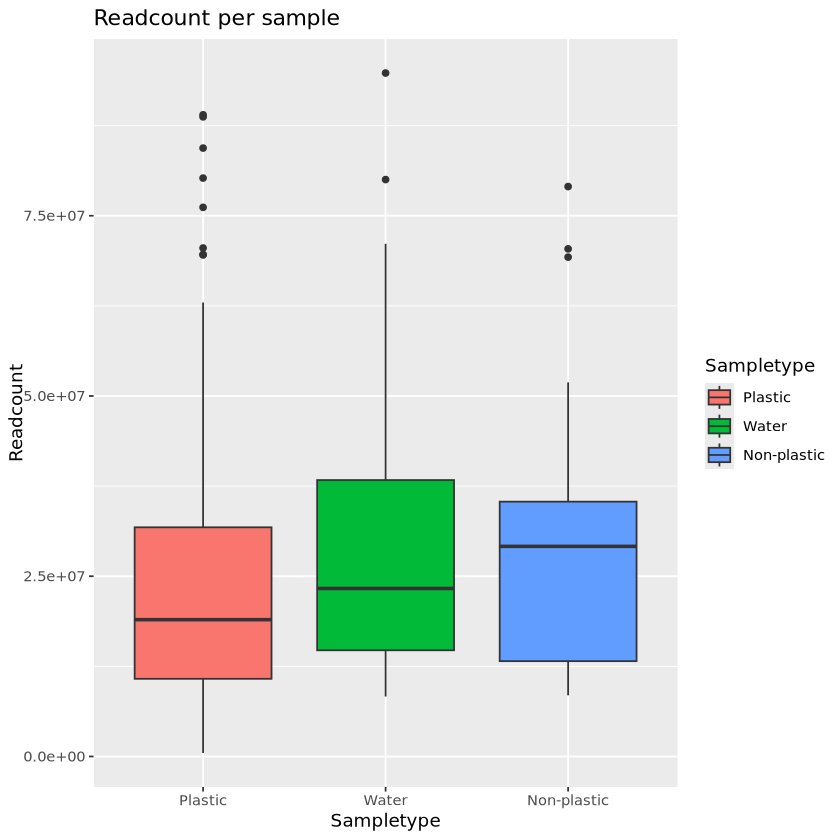

In [75]:
# Gives us a dataframe where row = sample and column = readcount
df_sample_readcount <- df_readcount %>%
    select(!Description) %>%
    select(contains("_1_val-Mut"))%>%
    pivot_longer(cols = everything(), names_to = "Sample", values_to = "Readcount") %>%
    mutate(Sample = str_remove(Sample, "_1_val-Mut")) %>%
    left_join(sample_metadata, by = join_by(Sample == run_accession)) %>%
    arrange(Sampletype, Substrate) %>%
    mutate(Sampletype = factor(Sampletype, levels = c("Plastic", "Water", "Non-plastic")))
#data %>%
#  arrange(val) %>%    # First sort by val. This sort the dataframe but NOT the factor levels
#  mutate(name=factor(name, levels=name))
head(df_sample_readcount)


plot_readcount <- df_sample_readcount %>%
    #filter(Readcount < 5000000) %>%
    ggplot(aes(Sampletype, Readcount, fill = Sampletype))+
    geom_boxplot()
    #geom_violin()

plot_readcount + labs(title = "Readcount per sample")
#plot_readcount + geom_jitter() + labs(title = "Readcount per sample, with jitter")

In [76]:
head(df_sample_metadata)

Sample,A109T:Mycobacterium tuberculosis katG mutations conferring resistance to isoniazid,A139V:Mycobacterium tuberculosis katG mutations conferring resistance to isoniazid,A254G:Mycobacterium tuberculosis embC mutant conferring resistance to ethambutol,T270I:Mycobacterium tuberculosis embC mutant conferring resistance to ethambutol,V287F:Mycobacterium tuberculosis embC mutant conferring resistance to ethambutol,G288V:Mycobacterium tuberculosis embC mutant conferring resistance to ethambutol,A375T:Escherichia coli EF-Tu mutants conferring resistance to Enacyloxin IIa,A381V:Mycobacterium tuberculosis rpoB with mutations conferring resistance to rifampicin,A412V:Mycobacterium tuberculosis rpsA mutations conferring resistance to pyrazinamide,⋯,M434V:Mycobacterium tuberculosis rpoB with mutations conferring resistance to rifampicin,Q490H:Mycobacterium tuberculosis rpoB with mutations conferring resistance to rifampicin,H525Q:Mycobacterium tuberculosis rpoC mutations confer resistance to rifampicin,S456W:Mycobacterium tuberculosis rpoB with mutations conferring resistance to rifampicin,run_accession,study_accession,Sampletype,Substrate,Latitude,Longitude
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>
DRR528401_1,0,0.25000000,0.1666667,0.1666667,0.1666667,0.1666667,1,0.052980132,0.0,⋯,0,0,0,0,DRR528401,PRJDB17400,Plastic,Plastic,35.834,139.607
DRR528401_2,0,0.11111111,0.0000000,0.0000000,0.0000000,0.0000000,1,0.008264463,0.2,⋯,0,0,0,0,DRR528401,PRJDB17400,Plastic,Plastic,35.834,139.607
DRR528402_1,0,0.00000000,0.0000000,0.0000000,0.0000000,0.0000000,1,0.023255814,0.0,⋯,0,0,0,0,DRR528402,PRJDB17400,Plastic,Plastic,35.648,139.841
DRR528402_2,0,0.00000000,0.0000000,0.0000000,0.0000000,0.0000000,1,0.000000000,0.0,⋯,0,0,0,0,DRR528402,PRJDB17400,Plastic,Plastic,35.648,139.841
DRR528403_1,0,0.02173913,0.0000000,0.0000000,0.0000000,0.0000000,1,0.000000000,0.0,⋯,0,0,0,0,DRR528403,PRJDB17400,Plastic,Plastic,35.911,140.496
DRR528403_2,0,0.00000000,0.0000000,0.0000000,0.0000000,0.0000000,1,0.107142857,0.0,⋯,0,0,0,0,DRR528403,PRJDB17400,Plastic,Plastic,35.911,140.496


## Mutation percent old
See also next cell

[1] "Plastic"     "Water"       "Non-plastic"

Dim df_long_sample:		 385926 3 
Dim df_long_sample_filtered:	 165846 3
df_long_sample
Num > 0:    10315 3 
Num == 0:  375611 3 

df_long_sample_filtered
Num > 0:    10087 3 
Num == 0:  155759 3 


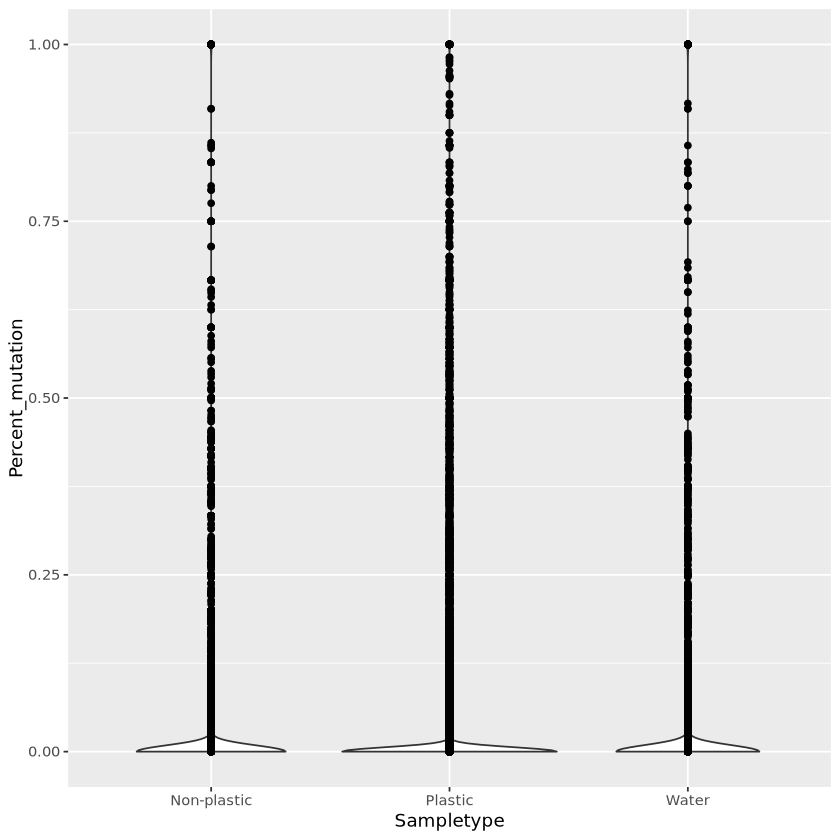

Num > 0:    10315 3 
Num == 0:  375611 3 


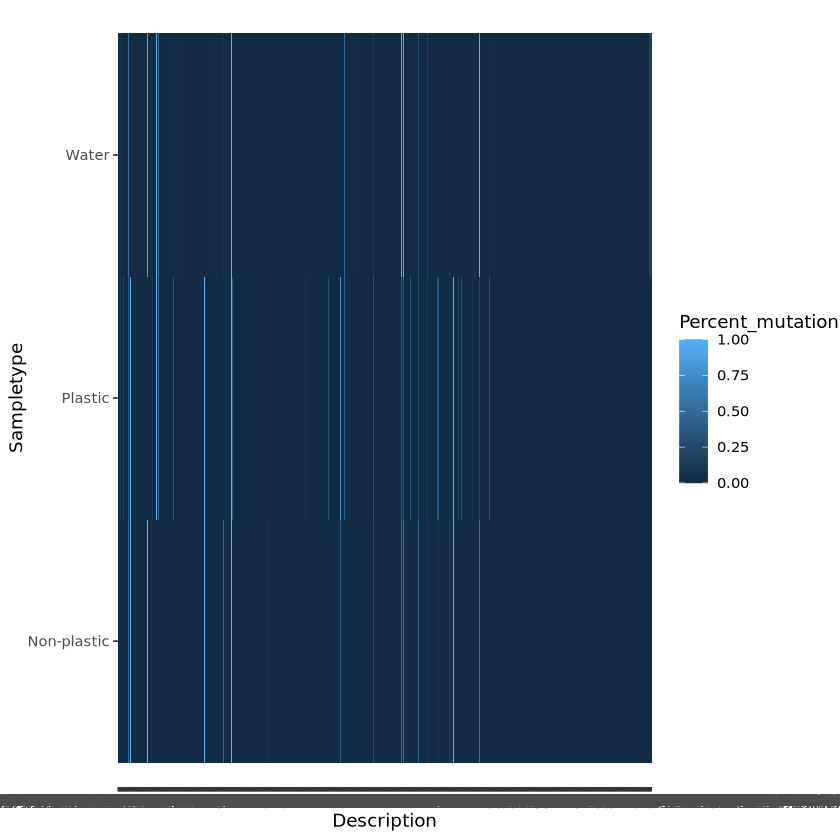

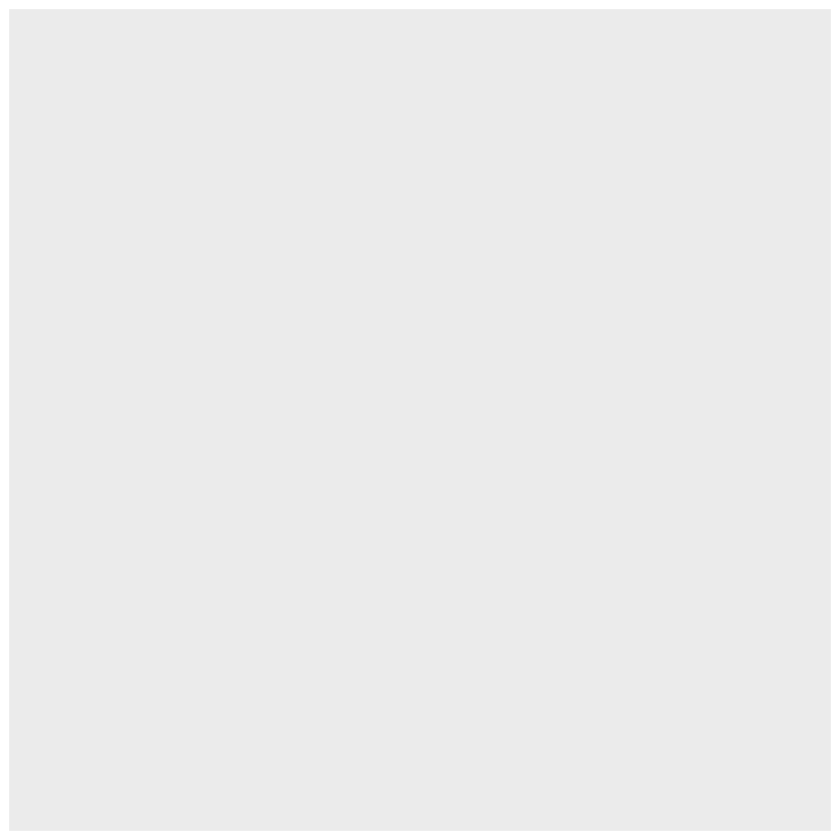

In [77]:
df_long_sample <- df_sample_metadata %>%
    select(Sampletype, contains(":")) %>%
    pivot_longer(!Sampletype, names_to = "Description", values_to = "Percent_mutation")

df_long_sample_filtered <- df_sample_metadata_filtered %>%
    select(Sampletype, contains(":")) %>%
    pivot_longer(!Sampletype, names_to = "Description", values_to = "Percent_mutation")

unique(df_long_sample$Sampletype)
cat("Dim df_long_sample:\t\t", dim(df_long_sample), "\n")
cat("Dim df_long_sample_filtered:\t", dim(df_long_sample_filtered))

cat("\ndf_long_sample\n")
df_long_sample %>%
    filter(Percent_mutation > 0) %>%
    dim() %>%
    cat("Num > 0:   ", ., "\n")

df_long_sample %>%
    filter(Percent_mutation == 0) %>%
    dim() %>%
    cat("Num == 0: ", ., "\n")

cat("\ndf_long_sample_filtered\n")
df_long_sample_filtered %>%
    filter(Percent_mutation > 0) %>%
    dim() %>%
    cat("Num > 0:   ", ., "\n")

df_long_sample_filtered %>%
    filter(Percent_mutation == 0) %>%
    dim() %>%
    cat("Num == 0: ", ., "\n")

figure_df <- df_long_sample
#figure_df <- df_long_sample_filtered

figure_df %>%
   ggplot(aes(Sampletype, Percent_mutation))+
       geom_violin()+
       geom_point()

figure_df %>%
    ggplot(aes(Description, Sampletype, fill = Percent_mutation))+
    geom_tile()

figure_df %>%
    filter(Percent_mutation > 0) %>%
    dim() %>%
    cat("Num > 0:   ", ., "\n")

figure_df%>%
    filter(Percent_mutation == 0) %>%
    dim() %>%
    cat("Num == 0: ", ., "\n")
    #ggplot(aes(Sampletype, Percent_mutation))+
    #geom_boxplot()

figure_df %>%
    ggplot()

In [78]:
head(df_genes_metadata, n = 3)

Description,DRR528401_1,DRR528401_2,DRR528402_1,DRR528402_2,DRR528403_1,DRR528403_2,DRR528404_1,DRR528404_2,DRR528405_1,⋯,Mutations,Name,Accession,Model Type,Parameter Type,CARD Short Name,source,AMR Gene Family,Drug Class,Resistance Mechanism
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
A109T:Mycobacterium tuberculosis katG mutations conferring resistance to isoniazid,0.0000000,0.0000000,NaN,0,0.00000000,0,0,0.5,0,⋯,A109T,Mycobacterium tuberculosis katG mutations conferring resistance to isoniazid,3003392,protein variant model,single resistance variant,Mtub_katG_INH,WHO-R,isoniazid resistant katG,isoniazid-like antibiotic,antibiotic target alteration
A139V:Mycobacterium tuberculosis katG mutations conferring resistance to isoniazid,0.2500000,0.1111111,NaN,0,0.02173913,0,0,0.0,0,⋯,A139V,Mycobacterium tuberculosis katG mutations conferring resistance to isoniazid,3003392,protein variant model,single resistance variant,Mtub_katG_INH,WHO-R,isoniazid resistant katG,isoniazid-like antibiotic,antibiotic target alteration
A254G:Mycobacterium tuberculosis embC mutant conferring resistance to ethambutol,0.1666667,0.0000000,0,0,0.00000000,0,NaN,NaN,NaN,⋯,A254G,Mycobacterium tuberculosis embC mutant conferring resistance to ethambutol,3003327,protein variant model,single resistance variant,Mtub_embC_EMB,Curated-R,ethambutol resistant embC,polyamine antibiotic,antibiotic target alteration


## Mutation percent new

In [79]:
df_long_genes <- df_genes_metadata %>%
    #select(Description, contains("_")) %>%
    pivot_longer(contains("_"), names_to = "Sample", values_to = "Percent_mutation")

df_long_all <- df_long_genes %>%
    mutate(run_accession = str_remove(Sample, "_1|_2")) %>%
    left_join(sample_metadata, by = join_by(run_accession)) %>%
    filter(Percent_mutation == is_double(Percent_mutation))
df_long_all[which(df_long_all$Description == "N596S:Mycobacterium tuberculosis katG mutations conferring resistance to isoniazid"), ]


Description,Mutations,Name,Accession,Model Type,Parameter Type,CARD Short Name,source,AMR Gene Family,Drug Class,Resistance Mechanism,Sample,Percent_mutation,run_accession,study_accession,Sampletype,Substrate,Latitude,Longitude
<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>
N596S:Mycobacterium tuberculosis katG mutations conferring resistance to isoniazid,N596S,Mycobacterium tuberculosis katG mutations conferring resistance to isoniazid,NA,NA,NA,NA,NA,NA,NA,NA,SRR26541456_1,1,SRR26541456,PRJNA886482,Plastic,PBAT,35.0158333333333,139.2222


Dim df_long_genes:		 385926 13 

df_long_sample
Num > 0:    10315 13 
Num == 0:  53307 13 


Warning message:
“Removed 322304 rows containing missing values or values outside the scale range
(`geom_point()`).”


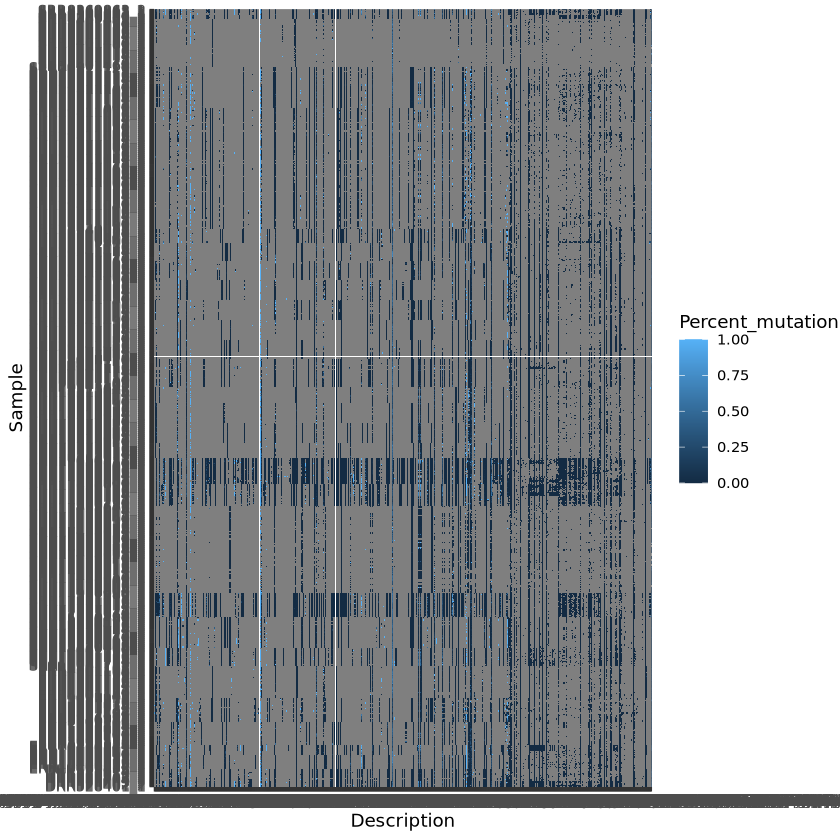

Num > 0:    10315 13 
Num == 0:  53307 13 


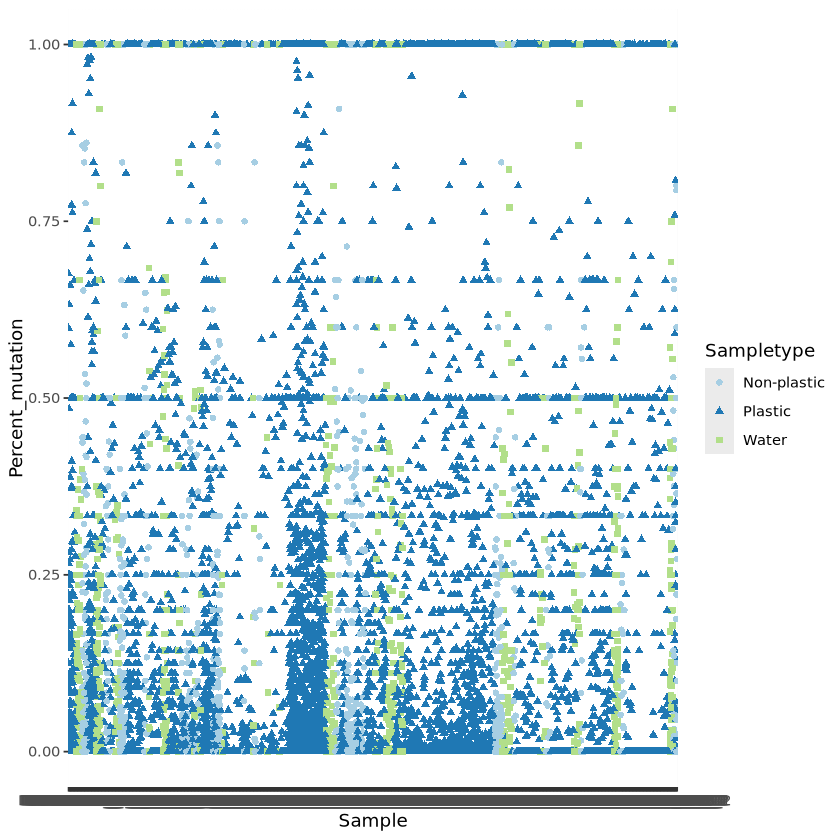

In [80]:

#df_long_genes_filtered <- df_genes_metadata_filtered %>%
#    select(Test, contains(":")) %>%
#    pivot_longer(!Test, names_to = "Description", values_to = "Percent_mutation")

#unique(df_long_genes$Test)
cat("Dim df_long_genes:\t\t", dim(df_long_genes), "\n")
#cat("Dim df_long_genes_filtered:\t", dim(df_long_genes_filtered))

cat("\ndf_long_sample\n")
df_long_genes %>%
    filter(Percent_mutation > 0) %>%
    dim() %>%
    cat("Num > 0:   ", ., "\n")

df_long_genes %>%
    filter(Percent_mutation == 0) %>%
    dim() %>%
    cat("Num == 0: ", ., "\n")

#cat("\ndf_long_genes_filtered\n")
#df_long_genes_filtered %>%
#    filter(Percent_mutation > 0) %>%
#    dim() %>%
#    cat("Num > 0:   ", ., "\n")
#
#df_long_genes_filtered %>%
#    filter(Percent_mutation == 0) %>%
#    dim() %>%
#    cat("Num == 0: ", ., "\n")

figure_df <- df_long_genes
#figure_df <- df_long_genes_filtered

figure_df %>%
    ggplot(aes(Description, Sample, fill = Percent_mutation))+
    geom_tile()

#figure_df %>%
 #   filter(`AMR Gene Family` != "ATP-binding cassette (ABC) antibiotic efflux pump;General Bacterial Porin with reduced permeability to beta-lactams;major facilitator superfamily (MFS) antibiotic efflux pump;resistance-nodulation-cell division (RND) antibiotic efflux pump") %>%
 #   ggplot(aes(Sample, `AMR Gene Family`))+
 #       geom_col(stat = "identity", position = "fill")

figure_df %>%
    # Remove the read direction to get common sample name
    mutate(run_accession = str_remove(Sample, "_1|_2")) %>%
    # Add the metadata by the common sample name
    left_join(x = ., y = sample_metadata, by = join_by(run_accession)) %>%
    ggplot(aes(Sample, Percent_mutation, col = Sampletype, shape = Sampletype))+
        geom_point()+
        scale_color_brewer(palette = "Paired")

figure_df %>%
    filter(Percent_mutation > 0) %>%
    dim() %>%
    cat("Num > 0:   ", ., "\n")

figure_df%>%
    filter(Percent_mutation == 0) %>%
    dim() %>%
    cat("Num == 0: ", ., "\n")
    #ggplot(aes(Test, Percent_mutation))+
    #geom_boxplot()